# This is a broker metrics related forecasting analysis for the metrics:

### query/bytes 
### query/cpu/time 
### query/node/bytes 
### query/node/time 
### query/node/ttfb 
### query/priority 
### query/time

In [22]:
from pydruid.client import *
from pydruid.utils import dimensions, filters, aggregators
import pandas as pd

In [23]:
query = PyDruid('http://test0.druidonk8s.druid.data-infra.shopee.io/', 'druid/v2')
query.set_basic_auth_credentials("admin", "s2Ysn5v5")

In [74]:
ts = query.scan(
    datasource='druid_cenarius_metrics_all',
    granularity='all',
    intervals='2022-07-01/2022-08-03',
    limit=100000,
    context={"timeout": 1000},
    columns=["__time","value"],
    filter=(filters.Dimension('metric') == 'query/cpu/time') & (filters.Dimension('service') == 'druid/historical')
    #paging_spec={'pagingIdentifies': {}, 'threshold': 1},
    #context={"timeout": 1000},
    #aggregations={'maxval': aggregators.longmax('value')},
)
df = query.export_pandas()
df = df.dropna(how='all') 
df['__time'] = pd.to_datetime(df['__time'], unit='ms').dt.tz_localize(None)
df = df.rename(columns={"__time":"ds","value":"y"})
display(df)

,ds,y
0,2022-07-18 06:52:00,372
1,2022-07-18 06:58:00,255
2,2022-07-18 06:59:00,311
3,2022-07-18 06:50:00,283
4,2022-07-18 06:59:00,284
...,...,...
26414,2022-08-02 23:57:00,753
26415,2022-08-02 23:57:00,357
26416,2022-08-02 23:57:00,344
26417,2022-08-02 23:59:00,1091


In [43]:
ts = query.timeseries(
    datasource='druid_cenarius_metrics_all',
    granularity='hour',
    intervals='2022-01-01/2022-08-03',
    #paging_spec={'pagingIdentifies': {}, 'threshold': 1},
    #context={"timeout": 1000},
    aggregations={'maxval': aggregators.longmax('value')},
    filter=(filters.Dimension('metric') == 'query/cpu/time') & (filters.Dimension('service') == 'druid/historical')
)
df = query.export_pandas()
df['ds'] = pd.to_datetime(df['timestamp']).dt.date
df.drop(columns=['timestamp'])
df = df.rename(columns={"maxval":"y"})

In [75]:
from prophet import Prophet

m = Prophet()
m.fit(df)

16:34:07 - cmdstanpy - INFO - Chain [1] start processing
16:34:23 - cmdstanpy - INFO - Chain [1] done processing


In [76]:
future = m.make_future_dataframe(periods=30)
future.tail()

,ds
8455,2022-11-26 23:59:00
8456,2022-11-27 23:59:00
8457,2022-11-28 23:59:00
8458,2022-11-29 23:59:00
8459,2022-11-30 23:59:00


In [77]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
8455,2022-11-26 23:59:00,-477741.514409,-3.169456e+08,3.241152e+08
8456,2022-11-27 23:59:00,-477649.613451,-3.195976e+08,3.295188e+08
8457,2022-11-28 23:59:00,-491098.579019,-3.225288e+08,3.338561e+08
8458,2022-11-29 23:59:00,-468999.726203,-3.263065e+08,3.366263e+08
8459,2022-11-30 23:59:00,-486861.460275,-3.302808e+08,3.399867e+08


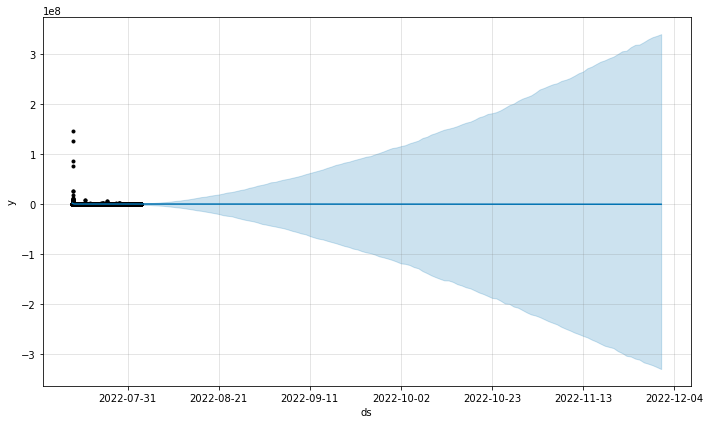

In [78]:
fig1 = m.plot(forecast)


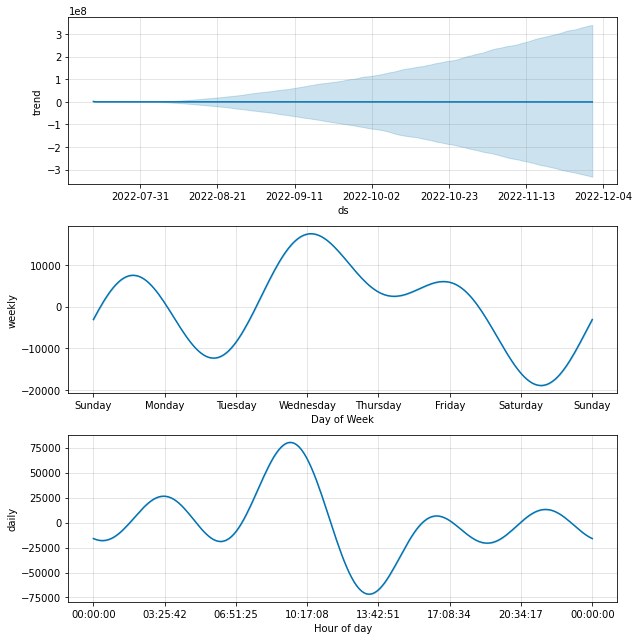

In [79]:
fig2 = m.plot_components(forecast)

In [80]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

In [81]:
plot_components_plotly(m, forecast)